In [31]:
import pandas as pd

df = pd.read_csv("genz_sentences_processed.csv")

df["Published_Date"] = pd.to_datetime(df["Published_Date"], errors="coerce")


In [32]:
df.head()
df.columns

Index(['Sentence', 'Source', 'Published_Date', 'processed_sentence'], dtype='object')

In [33]:
# Nepal Gen Z protest timeline
before_start = "2025-01-01"
before_end   = "2025-09-07"

during_start = "2025-09-08"
during_end   = "2025-09-13"

after_start  = "2025-09-14"

def assign_period(date):
    if pd.isna(date):
        return "unknown"
    d = str(date.date())
    if before_start <= d <= before_end:
        return "before"
    elif during_start <= d <= during_end:
        return "during"
    elif d >= after_start:
        return "after"
    else:
        return "unknown"

df["period"] = df["Published_Date"].apply(assign_period)


In [34]:
df["period"].value_counts()


,count
period,
after,932
before,226
during,222
unknown,111


In [35]:
genz_texts = df["processed_sentence"].astype(str).tolist()

In [36]:
genz_texts[:5]

['quiet reason trump losing gen z vox',
 'bos asks gen z employee come office online meeting reply go viral india today',
 '630 office else',
 'gen z savage reply bos win big internet hail work anywhe news18',
 'gen z v toxic bos whatsapp chat 630 office demand virtual meeting go viral moneycontrol']

In [37]:
import pandas as pd

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
sentiment_df = pd.read_csv(url)

sentiment_df = sentiment_df[["tweet", "label"]]
sentiment_df.columns = ["text", "sentiment"]

sentiment_df.head()

,text,sentiment
0,@user when a father is dysfunctional and is s...,0
1,@user @user thanks for #lyft credit i can't us...,0
2,bihday your majesty,0
3,#model i love u take with u all the time in ...,0
4,factsguide: society now #motivation,0


In [38]:
sentiment_df["sentiment"].value_counts()

,count
sentiment,
0,29720
1,2242


In [39]:
train_texts = sentiment_df["text"].astype(str).tolist()
train_labels = sentiment_df["sentiment"].tolist()

In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 40

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)


In [41]:
X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")

In [42]:
import numpy as np

y_train = np.array(train_labels)

In [43]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, random_state=42
)

In [44]:
print(X_tr.shape, y_tr.shape)
print(X_val.shape, y_val.shape)

(25569, 40) (25569,)
(6393, 40) (6393,)


In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),

    Conv1D(filters=64, kernel_size=5, activation="relu"),
    MaxPooling1D(pool_size=2),

    LSTM(64, return_sequences=False),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)


Epoch 1/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9217 - loss: 0.2830 - val_accuracy: 0.9499 - val_loss: 0.1459
Epoch 2/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.9633 - loss: 0.1187 - val_accuracy: 0.9600 - val_loss: 0.1142
Epoch 3/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.9817 - loss: 0.0560 - val_accuracy: 0.9573 - val_loss: 0.1278
Epoch 4/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9914 - loss: 0.0333 - val_accuracy: 0.9564 - val_loss: 0.1629
Epoch 5/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9963 - loss: 0.0165 - val_accuracy: 0.9576 - val_loss: 0.2084


In [47]:
genz_texts = df["processed_sentence"].astype(str).tolist()

In [48]:
genz_seq = tokenizer.texts_to_sequences(genz_texts)
genz_pad = pad_sequences(genz_seq, maxlen=MAX_LEN, padding="post")

In [49]:
sentiment_scores = model.predict(genz_pad)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [50]:
df["sentiment_score"] = sentiment_scores
df["sentiment_label"] = (df["sentiment_score"] >= 0.5).astype(int)

In [51]:
df["sentiment_label"].value_counts()

,count
sentiment_label,
0,1339
1,152


In [52]:
sentiment_trend = (
    df.groupby("period")["sentiment_label"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

sentiment_trend

sentiment_label,0,1
period,,
after,90.128755,9.871245
before,89.380531,10.619469
during,85.585586,14.414414
unknown,96.396396,3.603604


In [53]:
df.to_csv("genz_sentiment_results.csv", index=False)

<Axes: xlabel='period'>

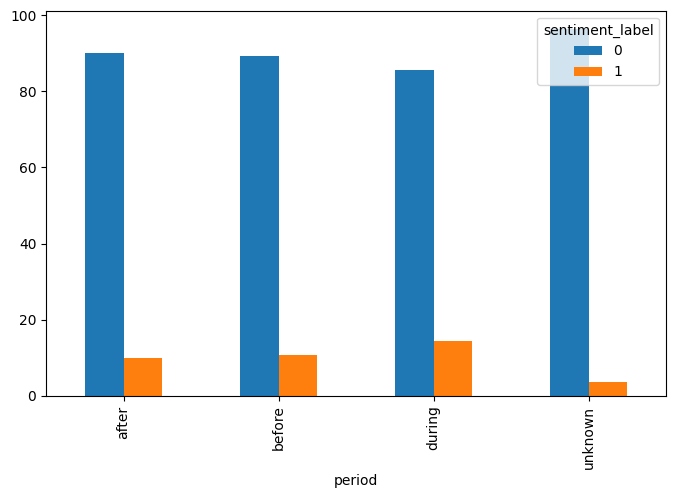

In [54]:
sentiment_trend.plot(kind="bar", figsize=(8,5))